In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

print("All imports successful.")

All imports successful.


In [6]:
# Load the dataset - go up one level from notebooks/ to ml/, then into data/
df = pd.read_csv('../data/destinations_raw.csv')

print(f"Shape: {df.shape} rows × {df.shape[1]} columns")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (155, 35) rows × 35 columns

First 3 rows:


,destination_id,destination_city,country,region,avg_annual_temp_c,seasonal_range_c,dry_season_months,cost_per_day_avg_usd,meal_budget_usd,hotel_night_avg_usd,flight_cost_usd,museum_count,monument_count,festival_score,beach_score,scenic_score,wellness_score,culture_score,hiking_score,nightlife_score,family_score,luxury_score,safety_score,tourist_density_score,adventure_sports_score,near_mountains,near_beach,best_season,visa_requirement,english_friendly_score,public_transport_score,latitude,longitude,source_label_hint,travel_style
0,DST-0001,Kathmandu,Nepal,South Asia,20.0,15.0,"Oct,Nov,Dec,Jan,Feb,Mar",35,4,25,800,8,12,7,1,8,3,6,9,4,3,1,7,5,9,1,0,Oct-Nov,Visa on Arrival,6,4,27.7172,85.3240,Himalayas trekking culture temples,Adventure
1,DST-0002,Queenstown,New Zealand,Oceania,12.0,18.0,"Dec,Jan,Feb,Mar",120,15,95,1100,5,3,5,3,9,4,4,8,6,7,6,9,7,10,1,0,Dec-Feb,eTA required,10,5,-45.0312,168.6626,Adventure sports bungee skiing,Adventure
2,DST-0003,Interlaken,Switzerland,Western Europe,9.0,22.0,"Jun,Jul,Aug,Sep",150,20,120,600,4,2,4,2,10,5,5,9,3,6,7,9,6,10,1,0,Jun-Sep,Schengen Visa,8,8,46.6863,7.8632,Alps paragliding lakes hiking,Adventure


In [7]:
# Display all column names
print("Column names:")
print(df.columns.tolist())
print(f"\nTotal columns: {len(df.columns)}")

# Data types
print("\nData types:")
print(df.dtypes.value_counts())

Column names:
['destination_id', 'destination_city', 'country', 'region', 'avg_annual_temp_c', 'seasonal_range_c', 'dry_season_months', 'cost_per_day_avg_usd', 'meal_budget_usd', 'hotel_night_avg_usd', 'flight_cost_usd', 'museum_count', 'monument_count', 'festival_score', 'beach_score', 'scenic_score', 'wellness_score', 'culture_score', 'hiking_score', 'nightlife_score', 'family_score', 'luxury_score', 'safety_score', 'tourist_density_score', 'adventure_sports_score', 'near_mountains', 'near_beach', 'best_season', 'visa_requirement', 'english_friendly_score', 'public_transport_score', 'latitude', 'longitude', 'source_label_hint', 'travel_style']

Total columns: 35

Data types:
int64      22
str         9
float64     4
Name: count, dtype: int64


In [8]:
# Missing values count
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing_df)}")
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found.")

Columns with missing values: 1
                  missing_count  missing_pct
seasonal_range_c              1     0.645161


In [9]:
# Check duplicates by destination_id
duplicates_by_id = df[df.duplicated(subset='destination_id', keep=False)]
print(f"Duplicate rows by destination_id: {len(duplicates_by_id)}")
if len(duplicates_by_id) > 0:
    print("\nDuplicate pairs (by ID):")
    print(duplicates_by_id[['destination_id', 'destination_city', 'country', 'travel_style']].sort_values('destination_id'))

# Check duplicates by city+country
duplicates_by_city = df[df.duplicated(subset=['destination_city', 'country'], keep=False)]
print(f"\nDuplicate rows by city+country: {len(duplicates_by_city)}")
if len(duplicates_by_city) > 0:
    print(duplicates_by_city[['destination_id', 'destination_city', 'country', 'travel_style']].sort_values('destination_city'))

Duplicate rows by destination_id: 0

Duplicate rows by city+country: 12
   destination_id destination_city       country travel_style
40       DST-0041        Cape Town  South Africa    Adventure
75       DST-0076        Cape Town  South Africa    Adventure
41       DST-0042         Maldives      Maldives       Luxury
78       DST-0079         Maldives      Maldives       Luxury
81       DST-0082       Montevideo       Uruguay      Culture
82       DST-0083       Montevideo       Uruguay      Culture
76       DST-0077          Nairobi         Kenya    Adventure
77       DST-0078          Nairobi         Kenya    Adventure
79       DST-0080         Santiago         Chile      Culture
80       DST-0081         Santiago         Chile      Culture
15       DST-0016           Sydney     Australia      Culture
74       DST-0075           Sydney     Australia      Culture


Travel Style Distribution (raw):
travel_style
Culture       50
Adventure     40
Budget        25
Relaxation    17
Family        14
Luxury         9
Name: count, dtype: int64

Percentage:
travel_style
Culture       32.3
Adventure     25.8
Budget        16.1
Relaxation    11.0
Family         9.0
Luxury         5.8
Name: count, dtype: float64


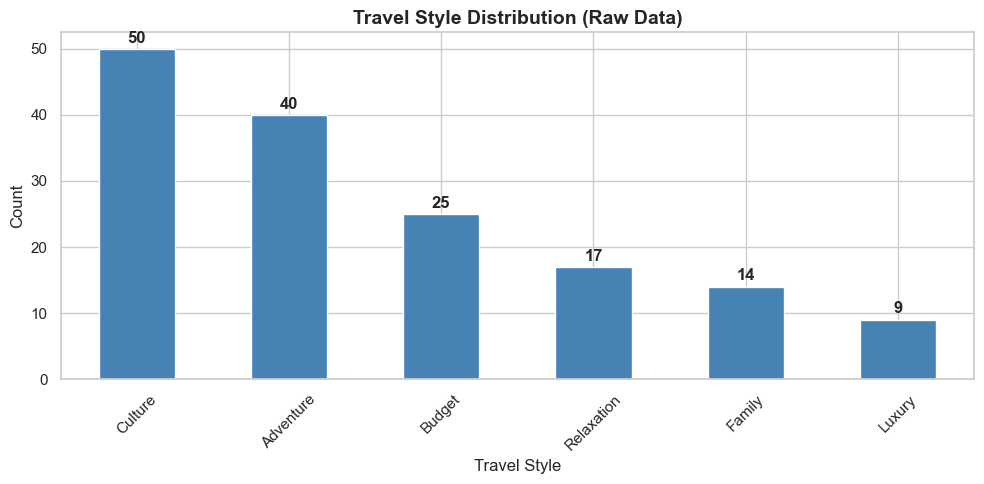

In [10]:
# Class distribution
print("Travel Style Distribution (raw):")
class_dist = df['travel_style'].value_counts()
print(class_dist)

# Percentage
print("\nPercentage:")
print((class_dist / len(df) * 100).round(1))

# Bar plot
plt.figure(figsize=(10, 5))
ax = class_dist.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Travel Style Distribution (Raw Data)', fontsize=14, fontweight='bold')
plt.xlabel('Travel Style')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Add value labels on bars
for i, v in enumerate(class_dist.values):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns ({len(numerical_cols)}):")
print(numerical_cols)

# Summary statistics
print("\nSummary statistics for numerical features:")
df[numerical_cols].describe().round(2)

Numerical columns (26):
['avg_annual_temp_c', 'seasonal_range_c', 'cost_per_day_avg_usd', 'meal_budget_usd', 'hotel_night_avg_usd', 'flight_cost_usd', 'museum_count', 'monument_count', 'festival_score', 'beach_score', 'scenic_score', 'wellness_score', 'culture_score', 'hiking_score', 'nightlife_score', 'family_score', 'luxury_score', 'safety_score', 'tourist_density_score', 'adventure_sports_score', 'near_mountains', 'near_beach', 'english_friendly_score', 'public_transport_score', 'latitude', 'longitude']

Summary statistics for numerical features:


,avg_annual_temp_c,seasonal_range_c,cost_per_day_avg_usd,meal_budget_usd,hotel_night_avg_usd,flight_cost_usd,museum_count,monument_count,festival_score,beach_score,scenic_score,wellness_score,culture_score,hiking_score,nightlife_score,family_score,luxury_score,safety_score,tourist_density_score,adventure_sports_score,near_mountains,near_beach,english_friendly_score,public_transport_score,latitude,longitude
count,155.00,154.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00
mean,17.88,14.08,91.29,11.74,70.16,558.71,13.49,13.06,5.57,3.63,7.03,4.25,5.35,3.56,4.62,4.66,4.15,7.74,5.90,3.88,0.45,0.46,6.48,5.17,20.64,28.82
std,7.24,6.97,63.66,7.19,57.63,215.79,17.55,12.48,1.82,3.12,1.88,1.85,2.13,2.46,2.06,1.43,2.13,1.06,1.52,2.47,0.50,0.50,1.96,2.09,27.77,72.91
min,2.00,2.00,25.00,3.00,18.00,300.00,1.00,1.00,1.00,1.00,2.00,1.00,2.00,1.00,1.00,1.00,1.00,6.00,2.00,1.00,0.00,0.00,3.00,2.00,-51.00,-156.33
25%,12.00,8.00,45.00,6.00,30.00,350.00,3.00,4.00,4.00,1.00,6.00,3.00,4.00,2.00,3.00,4.00,3.00,7.00,5.00,2.00,0.00,0.00,5.00,4.00,3.20,-2.35
50%,18.00,14.00,80.00,10.00,55.00,550.00,8.00,10.00,6.00,2.00,7.00,4.00,5.00,3.00,5.00,5.00,4.00,8.00,6.00,3.00,0.00,0.00,6.00,5.00,27.72,21.43
75%,25.00,18.00,120.00,15.00,90.00,700.00,18.00,15.00,7.00,6.50,8.00,5.00,7.00,5.00,6.00,5.00,5.00,9.00,7.00,6.00,1.00,1.00,8.00,7.00,42.65,89.40
max,29.00,35.00,350.00,40.00,320.00,1200.00,130.00,80.00,9.00,10.00,10.00,9.00,10.00,10.00,9.00,9.00,10.00,9.00,9.00,10.00,1.00,1.00,10.00,10.00,69.65,176.25


In [12]:
# Categorical columns (object type)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)

# Unique value counts for each categorical column
print("\nUnique value counts per categorical column:")
for col in categorical_cols:
    print(f"  {col}: {df[col].nunique()} unique values")

Categorical columns (9):
['destination_id', 'destination_city', 'country', 'region', 'dry_season_months', 'best_season', 'visa_requirement', 'source_label_hint', 'travel_style']

Unique value counts per categorical column:
  destination_id: 155 unique values
  destination_city: 149 unique values
  country: 79 unique values
  region: 14 unique values
  dry_season_months: 33 unique values
  best_season: 25 unique values
  visa_requirement: 10 unique values
  source_label_hint: 149 unique values
  travel_style: 6 unique values


C:\Users\Jawad\AppData\Local\Temp\ipykernel_4392\3906986004.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [13]:
# Check for leading/trailing whitespace in string columns
string_cols = df.select_dtypes(include=['object', 'string']).columns

whitespace_report = []
for col in string_cols:
    has_leading = df[col].astype(str).str.startswith(' ').any()
    has_trailing = df[col].astype(str).str.endswith(' ').any()
    if has_leading or has_trailing:
        whitespace_report.append({
            'column': col,
            'leading_spaces': has_leading,
            'trailing_spaces': has_trailing
        })

if whitespace_report:
    print("Columns with whitespace issues:")
    for w in whitespace_report:
        print(f"  {w['column']}: leading={w['leading_spaces']}, trailing={w['trailing_spaces']}")
else:
    print("No whitespace issues detected in string columns.")

No whitespace issues detected in string columns.


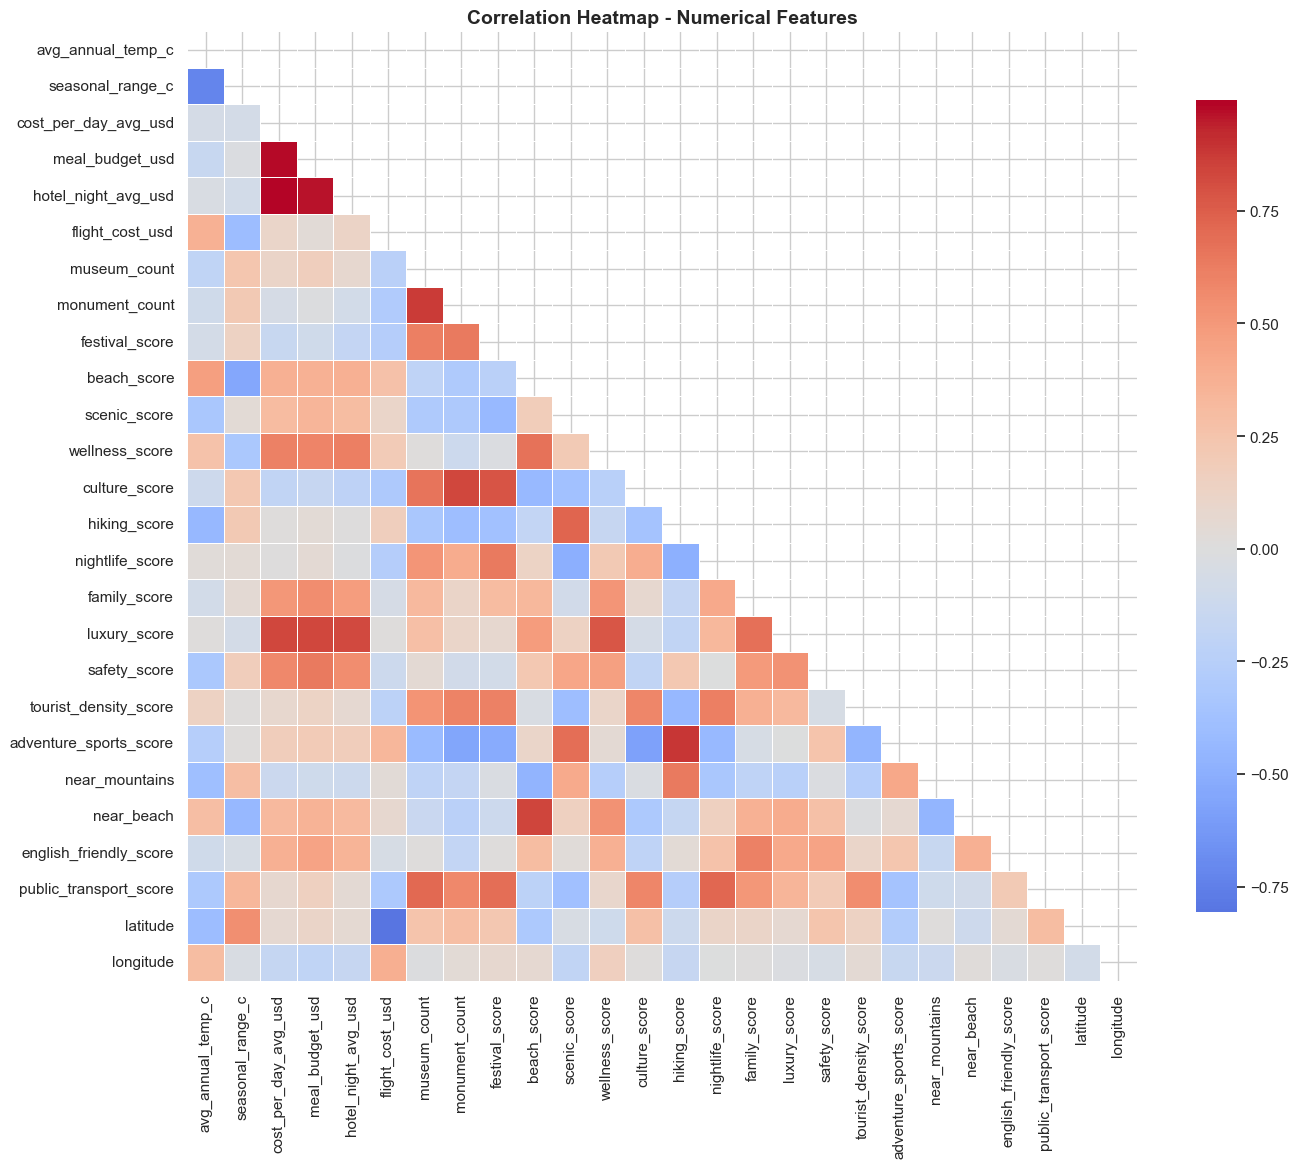


Top 10 correlations with cost_per_day_avg_usd:
hotel_night_avg_usd       0.995902
meal_budget_usd           0.976813
luxury_score              0.830140
wellness_score            0.612105
safety_score              0.576967
family_score              0.504056
english_friendly_score    0.371898
beach_score               0.371328
near_beach                0.325600
scenic_score              0.307755
Name: cost_per_day_avg_usd, dtype: float64


In [16]:
# Correlation matrix for numerical features
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, 
            annot=False, fmt='.2f', square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with cost_per_day_avg_usd
print("\nTop 10 correlations with cost_per_day_avg_usd:")
cost_corr = corr_matrix['cost_per_day_avg_usd'].abs().sort_values(ascending=False)
print(cost_corr.head(11).iloc[1:11])

In [17]:
import os
os.makedirs('../../experiments', exist_ok=True)

In [18]:
import os

# Create experiments directory if it doesn't exist
os.makedirs('../experiments', exist_ok=True)

# Export class distribution to CSV
class_dist_df = pd.DataFrame({
    'travel_style': class_dist.index,
    'count': class_dist.values,
    'percentage': (class_dist.values / len(df) * 100).round(1)
})
class_dist_df.to_csv('../experiments/class_distribution_raw.csv', index=False)
print("Saved: backend/ml/experiments/class_distribution_raw.csv")

# Export feature summary
feature_summary = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.values,
    'null_count': df.isnull().sum().values,
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2).values,
    'unique_count': df.nunique().values
})
feature_summary.to_csv('../experiments/feature_summary.csv', index=False)
print("Saved: backend/ml/experiments/feature_summary.csv")

print("\n=== EDA COMPLETE ===")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate IDs: {df.duplicated(subset='destination_id').sum()}")
print(f"Travel styles: {df['travel_style'].nunique()}")

Saved: backend/ml/experiments/class_distribution_raw.csv
Saved: backend/ml/experiments/feature_summary.csv

=== EDA COMPLETE ===
Total rows: 155
Total columns: 35
Missing values: 1
Duplicate IDs: 0
Travel styles: 6
